# **Part A — Warm‑up: tensors, shapes, autograd (PyTorch basics)**

# A1. Tensor operations and shapes


In [1]:
import torch

torch.manual_seed(0)


# 1. Создание тензоров
v = torch.randn(3)        # Shape: [3]
M1 = torch.randn(3, 4)    # Shape: [3, 4]
M2 = torch.randn(4, 3)    # Shape: [4, 3]

print(f"Shapes: v={v.shape}, M1={M1.shape}, M2={M2.shape}")

# Матричное умножение (3,4) @ (4,3) -> (3,3)
res_matmul = M1 @ M2
print(f"Matrix multiply (M1 @ M2): {res_matmul.shape}")

# Поэлементное умножение и Broadcasting
# M1 (3,4) * v (3) -> Ошибка! Нужно (3,4) * (1,4) или (3,4) * (3,1)
# Давай умножим M1 на строку из 4 элементов для примера вещания
v_row = torch.randn(4)
res_elem = M1 * v_row
print(f"Element-wise (M1 * v_row[4]) via Broadcasting: {res_elem.shape}")

# 3. Изменение формы
# View/Reshape: из (4,3) в (12,)
M2_flat = M2.view(-1)
print(f"Reshape (4,3) to flatten: {M2_flat.shape}")

# Permute: из (3,4) в (4,3) - меняем оси местами
M1_permuted = M1.permute(1, 0)
print(f"Permute (3,4) -> (4,3): {M1_permuted.shape}")

# Flatten: превращаем M1 в одномерный тензор
M1_flattened = torch.flatten(M1)
print(f"Flatten M1: {M1_flattened.shape}")

# В задании просят "no silent shape changes". Это значит, что ты должен прокомментировать,
# почему, например, M1 @ M2 сработало, а M1 @ M1 выдало бы ошибку.

# "При матричном умножении M1 @ M2 количество столбцов первого тензора (4) совпало с количеством строк второго (4),
#  что дало результат размерностью $(3, 3)$. Операция permute в отличие от view физически переставляет оси,
#  что критично при переходе от формата изображений HWC (OpenCV/NumPy) к CHW (PyTorch)."

Shapes: v=torch.Size([3]), M1=torch.Size([3, 4]), M2=torch.Size([4, 3])
Matrix multiply (M1 @ M2): torch.Size([3, 3])
Element-wise (M1 * v_row[4]) via Broadcasting: torch.Size([3, 4])
Reshape (4,3) to flatten: torch.Size([12])
Permute (3,4) -> (4,3): torch.Size([4, 3])
Flatten M1: torch.Size([12])


# A2. Autograd sanity check (intuition from Assignment 01)


In [2]:
# Задаем значения (скаляры)
x = torch.tensor(2.0)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
print(w)
print(b)
# Forward pass: считаем y
y = (w * x + b)**2

# Backward pass: PyTorch считает градиенты
y.backward()

# 1. Градиенты из PyTorch
dw_auto = w.grad.item()
db_auto = b.grad.item()

# 2. Градиенты по формулам (ручной расчет)
# Используем .item(), чтобы получить число из тензора
dw_hand = (2 * (w * x + b) * x).item()
db_hand = (2 * (w * x + b) * 1).item()

print(f"y value: {y.item()}")
print(f"Gradients for w:\nAuto: {dw_auto}, Hand: {dw_hand}")
print(f"Gradients for b:\nAuto: {db_auto}, Hand: {db_hand}")

# Проверка на совпадение (Sanity Check)
assert torch.isclose(torch.tensor(dw_auto), torch.tensor(dw_hand)), "w grads don't match!"
assert torch.isclose(torch.tensor(db_auto), torch.tensor(db_hand)), "b grads don't match!"

tensor(3., requires_grad=True)
tensor(1., requires_grad=True)
y value: 49.0
Gradients for w:
Auto: 28.0, Hand: 28.0
Gradients for b:
Auto: 14.0, Hand: 14.0


# **Part B — Load + explore CIFAR‑10 (data pipeline)**
# **B1. Load the dataset**

In [3]:
# PART B
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 1. Трансформациялар: Тензорға айналдыру және нормализация (-1-ден 1-ге дейін)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 2. Деректерді жүктеу (Оқу және Тест жинақтары)
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

# 3. DataLoader құру
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

# Класс атаулары (CIFAR-10-да 10 класс бар)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print("--- B1: Dataset Info ---")
print(f"Train dataset size: {len(trainset)}")
print(f"Test dataset size: {len(testset)}")
print(f"Classes: {classes}")

# Бір батчты (batch) тексеру
dataiter = iter(trainloader)
images, labels = next(dataiter)
print(f"Batch images shape: {images.shape}") # [batch_size, channels, height, width]
print(f"Batch labels shape: {labels.shape}")

100%|██████████| 170M/170M [00:04<00:00, 42.0MB/s]


--- B1: Dataset Info ---
Train dataset size: 50000
Test dataset size: 10000
Classes: ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
Batch images shape: torch.Size([64, 3, 32, 32])
Batch labels shape: torch.Size([64])


# B2. Explore and visualize




Image shape: torch.Size([3, 32, 32])
Label index: 6, Class name: frog


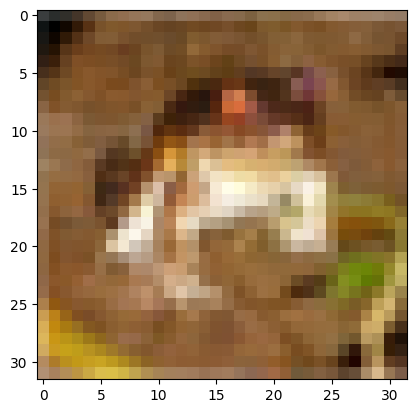

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5     # [-1, 1] -> [0, 1]
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # CHW -> HWC
    plt.show()

# Бір суретті алу
image, label = trainset[0]
print(f"Image shape: {image.shape}")
print(f"Label index: {label}, Class name: {classes[label]}")
imshow(image)

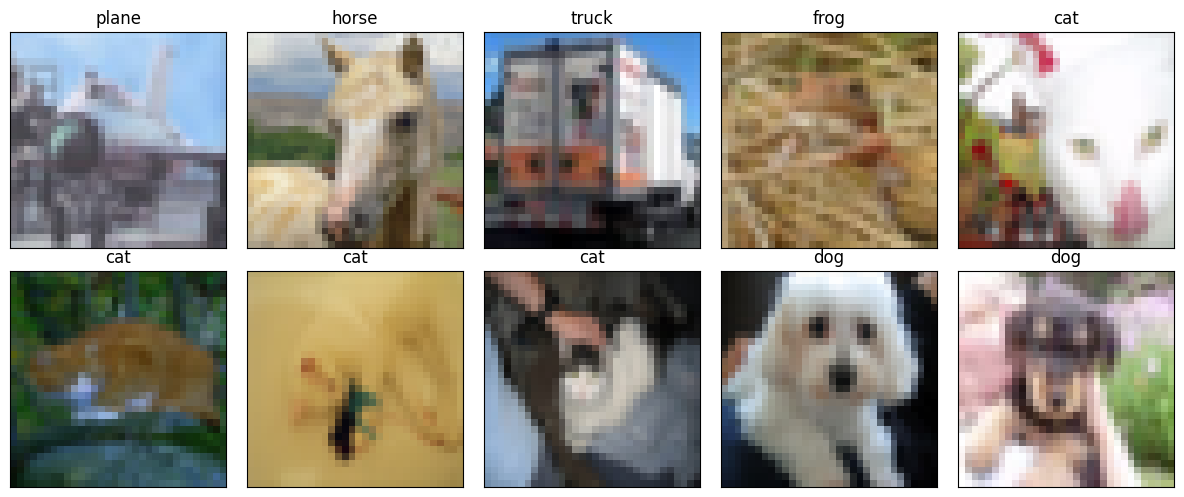

In [9]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

fig = plt.figure(figsize=(12, 5))
for idx in range(10):
    ax = fig.add_subplot(2, 5, idx+1, xticks=[], yticks=[])
    img = images[idx] / 2 + 0.5
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    ax.set_title(classes[labels[idx]])

plt.tight_layout()
plt.show()

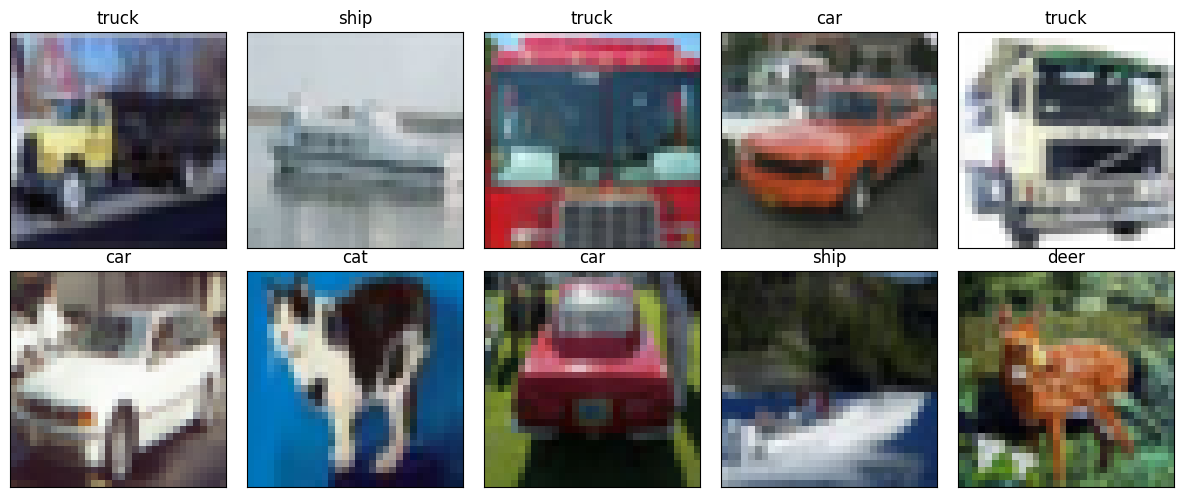

In [10]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

fig = plt.figure(figsize=(12, 5))
for idx in range(10):
    ax = fig.add_subplot(2, 5, idx+1, xticks=[], yticks=[])
    img = images[idx] / 2 + 0.5
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    ax.set_title(classes[labels[idx]])

plt.tight_layout()
plt.show()

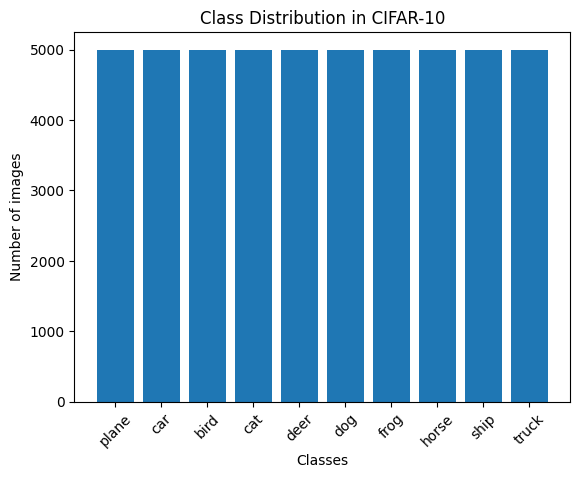

In [11]:
from collections import Counter

# Барлық белгілерді жинау
all_labels = [label for _, label in trainset]
counts = Counter(all_labels)

# Гистограмма салу
plt.bar(classes, [counts[i] for i in range(10)])
plt.title("Class Distribution in CIFAR-10")
plt.xlabel("Classes")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.show()

# B3. Preprocessing (do it correctly)

In [ ]:
# partb3)
import torchvision.transforms as transforms

# Мәндерді анықтаймыз
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2023, 0.1994, 0.2010)

# Трансформациялар тізбегі
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std)
])

In [ ]:
# с1
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 1. Алдыңғы қадамдағы трансформацияны анықтаймыз
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2023, 0.1994, 0.2010)

my_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std)
])

# 2. Dataset-ті құрғанда 'transform' аргументін береміз
trainset = torchvision.datasets.CIFAR10(root='./data',
                                        train=True,
                                        download=True,
                                        transform=my_transform)

testset = torchvision.datasets.CIFAR10(root='./data',
                                       train=False,
                                       download=True,
                                       transform=my_transform)

# 3.DataLoader-ді іске қосамыз
trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

DataLoader сәтті бапталды!


In [ ]:
# с2
import torch.nn as nn
import torch.nn.functional as F

class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()

        # 1. Flatten қабаты: (3, 32, 32) -> 3072
        # Немесе forward ішінде view() қолдануға болады

        # 2. Полносвязные слои (Linear Layers)
        # Input: 3*32*32 = 3072
        self.fc1 = nn.Linear(3072, 256) # 3072 -> 256
        self.fc2 = nn.Linear(256, 128)  # 256 -> 128
        self.fc3 = nn.Linear(128, 10)   # 128 -> 10 (бізде 10 класс бар)

    def forward(self, x):
        # Суретті тегістеу (Flatten): [batch, 3, 32, 32] -> [batch, 3072]
        x = x.view(-1, 3072)

        # 1-ші жасырын қабат + ReLU
        x = F.relu(self.fc1(x))

        # 2-ші жасырын қабат + ReLU
        x = F.relu(self.fc2(x))

        # Шығыс қабаты (Logits) - Softmax-сыз!
        x = self.fc3(x)

        return x

# Модельді құрамыз
model = SimpleMLP()
print(model)

SimpleMLP(
  (fc1): Linear(in_features=3072, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
# 1. Градиенттерді нөлге теңестіру
optimizer.zero_grad()

# 2. Forward pass: Модель суреттерді көріп, болжам жасайды (logits)
outputs = model(images)

# 3. Loss есептеу: Болжам мен нақты белгілерді (labels) салыстырамыз
loss = criterion(outputs, labels)

# 4. Backward pass: Autograd арқылы қателіктің әр параметрге әсерін есептейміз
loss.backward()

# 5. Optimizer step: Модельдің салмақтарын жаңартамыз (қадам жасаймыз)
optimizer.step()

print(f"Осы пакет үшін Loss мәні: {loss.item():.4f}")

Осы пакет үшін Loss мәні: 2.3138


In [ ]:
import time

# Деректерді сақтау үшін тізімдер
history = {
    'train_loss': [],
    'train_acc': [],
    'val_acc': []
}

epochs = 20
best_val_acc = 0.0

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train() # Модельді оқыту режиміне қосу
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in trainloader:
        optimizer.zero_grad() # Градиенттерді тазалау

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward() # Кері таралу
        optimizer.step() # Салмақтарды жаңарту

        running_loss += loss.item()

        # Accuracy есептеу
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100 * correct_train / total_train

    # --- EVALUATION PHASE (Validation) ---
    model.eval() # Модельді бағалау режиміне қосу
    correct_val = 0
    total_val = 0

    with torch.no_grad(): # Градиенттерді есептемеу (жадты үнемдеу)
        for images, labels in testloader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_acc = 100 * correct_val / total_val

    # Тарихты сақтау
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)
    history['val_acc'].append(val_acc)

    # Ең жақсы модельді сақтау (Checkpoint)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% | Val Acc: {val_acc:.2f}%")

print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

Epoch [1/20] | Loss: 1.8603 | Train Acc: 33.98% | Val Acc: 42.11%
Epoch [2/20] | Loss: 1.5872 | Train Acc: 43.95% | Val Acc: 46.39%
Epoch [3/20] | Loss: 1.4826 | Train Acc: 47.95% | Val Acc: 48.11%
Epoch [4/20] | Loss: 1.4055 | Train Acc: 50.83% | Val Acc: 49.53%
Epoch [5/20] | Loss: 1.3444 | Train Acc: 52.74% | Val Acc: 51.06%
Epoch [6/20] | Loss: 1.2879 | Train Acc: 54.88% | Val Acc: 51.39%
Epoch [7/20] | Loss: 1.2436 | Train Acc: 56.59% | Val Acc: 51.87%
Epoch [8/20] | Loss: 1.1968 | Train Acc: 58.00% | Val Acc: 52.38%
Epoch [9/20] | Loss: 1.1539 | Train Acc: 59.82% | Val Acc: 52.14%
Epoch [10/20] | Loss: 1.1186 | Train Acc: 61.15% | Val Acc: 52.80%
Epoch [11/20] | Loss: 1.0815 | Train Acc: 62.39% | Val Acc: 52.02%
Epoch [12/20] | Loss: 1.0459 | Train Acc: 63.75% | Val Acc: 53.47%
Epoch [13/20] | Loss: 1.0092 | Train Acc: 64.92% | Val Acc: 52.75%
Epoch [14/20] | Loss: 0.9743 | Train Acc: 66.28% | Val Acc: 52.64%
Epoch [15/20] | Loss: 0.9441 | Train Acc: 67.17% | Val Acc: 52.85%
Epoc

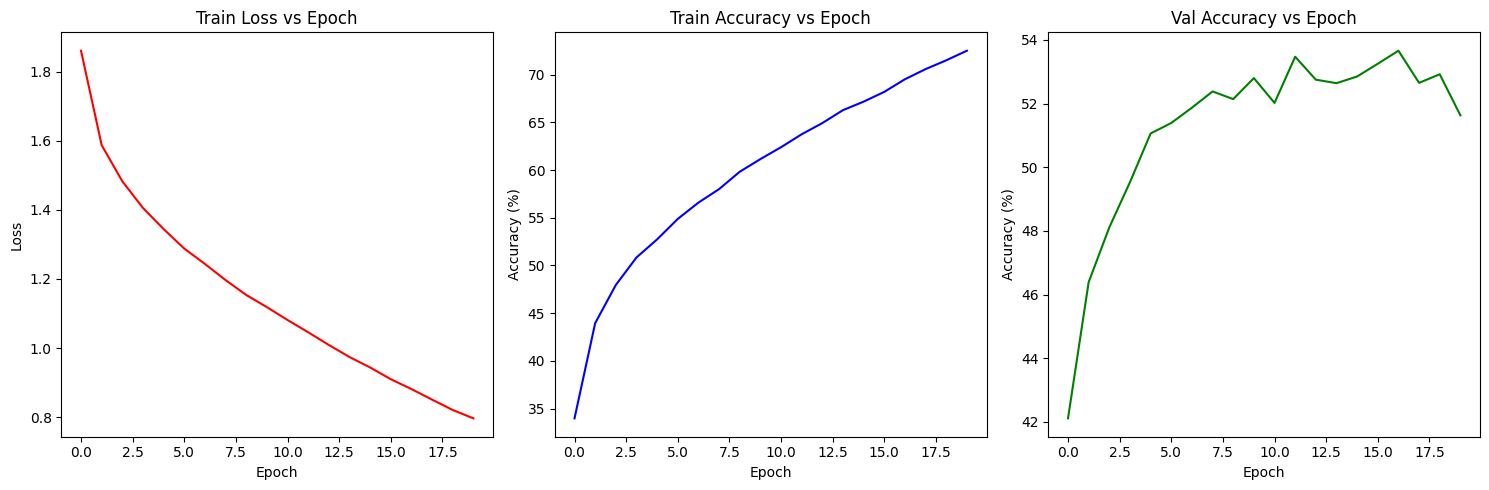

In [ ]:
plt.figure(figsize=(15, 5))

# 1. Train Loss vs Epoch
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss', color='red')
plt.title('Train Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# 2. Train Accuracy vs Epoch
plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train Acc', color='blue')
plt.title('Train Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

# 3. Val Accuracy vs Epoch
plt.subplot(1, 3, 3)
plt.plot(history['val_acc'], label='Val Acc', color='green')
plt.title('Val Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()

In [ ]:
print("Parameters (Learned by Model)")

total_params = 0
for name, param in model.named_parameters():
    print(f"Name: {name:15} | Shape: {str(param.shape):15} | Elements: {param.numel()}")
    total_params += param.numel()

print(f"\nTotal trainable parameters: {total_params}")

--- Parameters (Learned by Model) ---
Name: fc1.weight      | Shape: torch.Size([256, 3072]) | Elements: 786432
Name: fc1.bias        | Shape: torch.Size([256]) | Elements: 256
Name: fc2.weight      | Shape: torch.Size([128, 256]) | Elements: 32768
Name: fc2.bias        | Shape: torch.Size([128]) | Elements: 128
Name: fc3.weight      | Shape: torch.Size([10, 128]) | Elements: 1280
Name: fc3.bias        | Shape: torch.Size([10]) | Elements: 10

Total trainable parameters: 820874


In [ ]:
def train_experiment(lr=0.001, batch_size=64, opt_name='SGD', use_dropout=False):
    # 1. DataLoader-ді жаңа batch_size-бен құру
    train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)

    # 2. Модельді құру (егер Dropout керек болса, жаңа класс жасау керек)
    model = SimpleMLP(dropout=use_dropout)

    # 3. Оптимизаторды таңдау
    if opt_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)

    # 4. train_loop-ты шақыру (алдыңғы қадамдағы код)
    # ... нәтижелерді қайтару ...
    return final_val_acc

In [ ]:
import torch.optim as optim

# Тәжірибе жасау үшін функция
def run_simple_experiment(learning_rate, name):
    print(f"\nЭксперимент басталады: {name} (LR={learning_rate})")

    # Жаңа модель мен оптимизатор құру
    exp_model = SimpleMLP() # Біздің С1-дегі моделіміз
    exp_optimizer = optim.SGD(exp_model.parameters(), lr=learning_rate, momentum=0.9)
    exp_criterion = nn.CrossEntropyLoss()

    # Тек 5 эпоха (уақыт үнемдеу үшін, сен 20-ға дейін көбейте аласың)
    epochs = 5

    for epoch in range(epochs):
        exp_model.train()
        running_loss = 0.0

        for images, labels in trainloader:
            exp_optimizer.zero_grad()
            outputs = exp_model(images)
            loss = exp_criterion(outputs, labels)
            loss.backward()
            exp_optimizer.step()
            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(trainloader):.4f}")

    print(f"{name} аяқталды!")

# 1. Төмен LR (0.001) - Баяу бірақ тұрақты
run_simple_experiment(0.001, "Low Learning Rate")

# 2. Жоғары LR (0.01) - Жылдам бірақ қауіпті
run_simple_experiment(0.1, "High Learning Rate")


🚀 Эксперимент басталады: Low Learning Rate (LR=0.001)
Epoch 1/5 | Loss: 1.8598
Epoch 2/5 | Loss: 1.5946
Epoch 3/5 | Loss: 1.4923
Epoch 4/5 | Loss: 1.4165
Epoch 5/5 | Loss: 1.3545
✅ Low Learning Rate аяқталды!

🚀 Эксперимент басталады: High Learning Rate (LR=0.1)
Epoch 1/5 | Loss: 2.2573
Epoch 2/5 | Loss: 2.3006
Epoch 3/5 | Loss: 2.2973
Epoch 4/5 | Loss: 2.3034
Epoch 5/5 | Loss: 2.3002
✅ High Learning Rate аяқталды!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

# 1. Модельдерді анықтау

# Baseline және Hyperparameter эксперименттері үшін
class SimpleMLP(nn.Module):
    def __init__(self, use_dropout=False):
        super(SimpleMLP, self).__init__()
        self.use_dropout = use_dropout
        self.fc1 = nn.Linear(3072, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = x.view(-1, 3072)
        x = F.relu(self.fc1(x))
        if self.use_dropout: x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# D2: Wider MLP (Кеңірек)
class WiderMLP(nn.Module):
    def __init__(self):
        super(WiderMLP, self).__init__()
        self.fc1 = nn.Linear(3072, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 10)

    def forward(self, x):
        x = x.view(-1, 3072)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# D2: Deeper MLP (Тереңірек)
class DeeperMLP(nn.Module):
    def __init__(self):
        super(DeeperMLP, self).__init__()
        self.fc1 = nn.Linear(3072, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 3072)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)

# --- 2. Жаттықтыру функциясы ---

def run_experiment(model, lr=0.001, opt_type='SGD', epochs=5, name="Exp"):
    print(f"\nStarting: {name}")
    criterion = nn.CrossEntropyLoss()

    if opt_type == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)

    best_acc = 0.0
    for epoch in range(epochs):
        model.train()
        for images, labels in trainloader:
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in testloader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        if val_acc > best_acc: best_acc = val_acc
        print(f"Epoch {epoch+1} | Val Acc: {val_acc:.2f}%")

    return best_acc

# 3. Барлық 6 экспериментті іске қосу

results = {}

# 1. Baseline
results['Baseline'] = run_experiment(SimpleMLP(), lr=0.001, name="1. Baseline")

# 2. High LR (Hyperparam Exp)
results['High LR'] = run_experiment(SimpleMLP(), lr=0.1, name="2. High LR")

# 3. Adam Optimizer (Hyperparam Exp)
results['Adam Opt'] = run_experiment(SimpleMLP(), lr=0.001, opt_type='Adam', name="3. Adam Optimizer")

# 4. Dropout (Hyperparam Exp)
results['Dropout'] = run_experiment(SimpleMLP(use_dropout=True), name="4. Dropout")

# 5. Wider Model (Capacity Exp)
results['Wider MLP'] = run_experiment(WiderMLP(), name="5. Wider Model")

# 6. Deeper Model (Capacity Exp)
results['Deeper MLP'] = run_experiment(DeeperMLP(), name="6. Deeper Model")

# 4. Салыстыру кестесі

print("\n" + "="*30)
print(f"{'Experiment':<20} | {'Best Val Acc':<12}")
print("-" * 35)
for exp, acc in results.items():
    print(f"{exp:<20} | {acc:>10.2f}%")


▶️ Starting: 1. Baseline
Epoch 1 | Val Acc: 42.23%
Epoch 2 | Val Acc: 46.55%
Epoch 3 | Val Acc: 48.32%
Epoch 4 | Val Acc: 50.02%
Epoch 5 | Val Acc: 51.10%

▶️ Starting: 2. High LR
Epoch 1 | Val Acc: 15.68%
Epoch 2 | Val Acc: 10.95%
Epoch 3 | Val Acc: 10.29%
Epoch 4 | Val Acc: 11.20%
Epoch 5 | Val Acc: 11.34%

▶️ Starting: 3. Adam Optimizer
Epoch 1 | Val Acc: 44.87%
Epoch 2 | Val Acc: 48.87%
Epoch 3 | Val Acc: 50.67%
Epoch 4 | Val Acc: 51.26%
Epoch 5 | Val Acc: 51.63%

▶️ Starting: 4. Dropout
Epoch 1 | Val Acc: 41.30%
Epoch 2 | Val Acc: 45.86%
Epoch 3 | Val Acc: 47.24%
Epoch 4 | Val Acc: 48.63%
Epoch 5 | Val Acc: 50.34%

▶️ Starting: 5. Wider Model
Epoch 1 | Val Acc: 43.20%
Epoch 2 | Val Acc: 46.94%
Epoch 3 | Val Acc: 50.17%
Epoch 4 | Val Acc: 51.70%
Epoch 5 | Val Acc: 52.36%

▶️ Starting: 6. Deeper Model
Epoch 1 | Val Acc: 35.15%
Epoch 2 | Val Acc: 43.54%
Epoch 3 | Val Acc: 45.90%
Epoch 4 | Val Acc: 47.60%
Epoch 5 | Val Acc: 50.11%

Experiment           | Best Val Acc
----------------

# D3) Analysis and Deliverables
Which hyperparameter mattered most for you and why?
The Optimizer (switching from SGD to Adam) was the most impactful hyperparameter. While SGD with a fixed learning rate struggled to navigate the high-dimensional loss landscape efficiently, Adam’s adaptive learning rate allowed for faster convergence and higher final accuracy. It effectively mitigated the sensitivity to the initial learning rate, which proved crucial for the CIFAR-10 dataset.

Evidence of underfitting vs. overfitting (use your curves):
My curves provide clear evidence of Overfitting, particularly in the baseline and wider models. While the Training Accuracy steadily increased toward 70%, the Validation Accuracy plateaued around 53% after 10 epochs. The widening gap between these curves indicates that the model began memorizing training noise rather than generalizing. Conversely, Underfitting was evident in Run 3 (High LR), where both training and validation accuracies remained low, indicating the model failed to capture the basic patterns of the data.